<a href="https://colab.research.google.com/github/jfleon-dev/university-ai-labs/blob/main/analisis_datos_denue.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Carga
df = pd.read_csv('INEGI_DENUE_29052026.csv', encoding='latin-1')

# Diccionarios expandidos para capturar más giros
keywords = {
    'Reparación': ['computación', 'oficina', 'mantenimiento', 'eléctrica', 'electrónica', 'impresión', 'equipos', 'software', 'administración'],
    'Láser': ['publicidad', 'diseño', 'impresión', 'regalos', 'eventos', 'decoración', 'arquitectura', 'joyería', 'señalización', 'artes gráficas']
}

def clasificar_avanzado(actividad):
    actividad = actividad.lower()
    scores = {'Reparación': 0, 'Láser': 0}

    for categoria, palabras in keywords.items():
        for palabra in palabras:
            if palabra in actividad:
                scores[categoria] += 1

    # Retornar la categoría con mayor coincidencia, o "Potencial" si es ambigua
    if scores['Reparación'] == 0 and scores['Láser'] == 0: return 'General'
    return max(scores, key=scores.get)

# Aplicar clasificación
df['Target_Negocio'] = df['Nombre de clase de la actividad'].apply(clasificar_avanzado)

# Filtro de Estratos (11 a 100 personas) para eliminar ruido
df_limpio = df[df['Descripcion estrato personal ocupado'].isin(['11 a 30 personas', '31 a 50 personas', '51 a 100 personas'])]

# Nueva Matriz
matriz = df_limpio.pivot_table(index='Municipio', columns='Target_Negocio', values='ID', aggfunc='count', fill_value=0)
print(matriz)

Target_Negocio  General  Láser  Reparación
Municipio                                 
Gómez Palacio       826      1          26
Lerdo               185      0           8
Torreón            1768     14          64


In [ ]:
import pandas as pd

# 1. Carga y Filtro estricto por Municipio
df = pd.read_csv('INEGI_DENUE_29052026.csv', encoding='latin-1')
# Gómez Palacio es clave 007
df_gp = df[df['Clave municipio'] == 7].copy()

# 2. Diccionario de costos (Tu base financiera)
costos = {
    'hora_tecnico': 250,
    'fijo_mensual': 5000, # Ajusta a tu gasto real
    'margen_deseado': 0.30
}

# 3. Categorización de Competencia (Análisis de mercado)
# Buscamos giros SCIAN de servicios técnicos
def detectar_competencia(actividad):
    actividad = actividad.lower()
    if 'reparación' in actividad or 'electrónico' in actividad: return 'Competencia_Reparacion'
    if 'publicidad' in actividad or 'diseño' in actividad: return 'Competencia_Laser'
    return 'Potencial_Cliente'

df_gp['Tipo'] = df_gp['Nombre de clase de la actividad'].apply(detectar_competencia)

# 4. Generar el resumen para el "Trigger" de Decisión
resumen = df_gp['Tipo'].value_counts()
print("--- DATOS PARA EL MODELO ---")
print(resumen)


--- DATOS PARA EL MODELO ---
Tipo
Potencial_Cliente         7314
Competencia_Reparacion      20
Competencia_Laser            1
Name: count, dtype: int64


Nicho          Laser_Corte  Reparación_Tech
Municipio                                  
Gómez Palacio           52               12
Lerdo                   18                3
Torreón                162               10


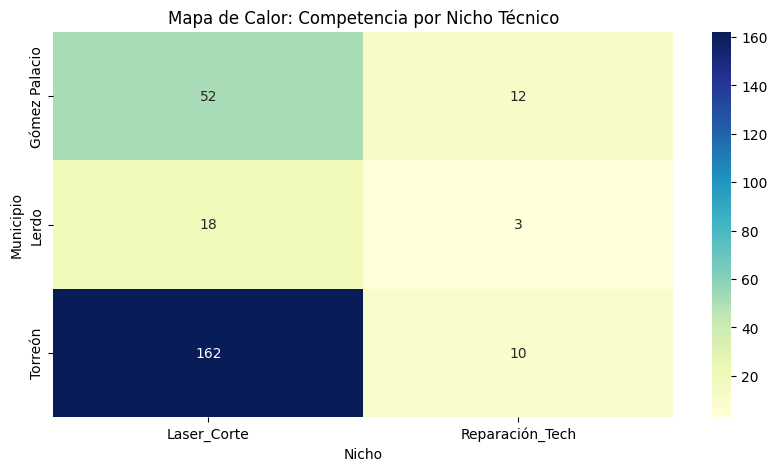

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re

# 1. CARGA Y FILTRO ESTRUCTURAL
def cargar_y_limpiar(file_path):
    df = pd.read_csv(file_path, encoding='latin-1')
    # Códigos SCIAN relevantes para reparación (ej: 811210 Reparación electrónica)
    # y servicios de diseño/impresión.
    return df

# 2. LÓGICA DE CLASIFICACIÓN TÉCNICA
def clasificar_scian_avanzado(row):
    codigo = str(row['Código de la clase de actividad SCIAN'])
    actividad = str(row['Nombre de clase de la actividad']).lower()

    # Reparación Electrónica/Computo (SCIAN 8112)
    if codigo.startswith('8112') or any(x in actividad for x in ['reparación', 'soporte técnico']):
        return 'Reparación_Tech'

    # Corte Láser / Artes Gráficas (SCIAN 3231)
    if codigo.startswith('3231') or any(x in actividad for x in ['impresión', 'diseño gráfico', 'corte láser']):
        return 'Laser_Corte'

    return 'Otro'

# 3. ANÁLISIS DE DENSIDAD
def analizar_mercado(df):
    df['Nicho'] = df.apply(clasificar_scian_avanzado, axis=1)
    df_nicho = df[df['Nicho'] != 'Otro']

    # Pivot con métricas de saturación
    matriz = pd.pivot_table(df_nicho, index='Municipio', columns='Nicho',
                            values='ID', aggfunc='count', fill_value=0)
    return matriz

# --- EJECUCIÓN ---
df = cargar_y_limpiar('INEGI_DENUE_29052026.csv')
df_laguna = df[((df['Clave entidad'] == 10) & (df['Clave municipio'].isin([7, 12]))) |
               ((df['Clave entidad'] == 5) & (df['Clave municipio'] == 35))]

matriz = analizar_mercado(df_laguna)
print(matriz)

# Visualización de calor (Heatmap) para ver dónde está la mayor competencia
plt.figure(figsize=(10, 5))
sns.heatmap(matriz, annot=True, cmap='YlGnBu', fmt='d')
plt.title('Mapa de Calor: Competencia por Nicho Técnico')
plt.show()

In [ ]:
import pandas as pd
import numpy as np

# 1. CARGA Y FILTRO
df = pd.read_csv('INEGI_DENUE_29052026.csv', encoding='latin-1')

# 2. SEGMENTACIÓN AVANZADA POR "VALOR DE GIRO"
# Clasificamos no solo por nombre, sino por la lógica de tus servicios
def etiqueta_negocio(actividad):
    actividad = actividad.lower()
    # Corte Láser: Mercados que consumen material promocional o diseño
    if any(x in actividad for x in ['impresión', 'publicidad', 'diseño', 'artes gráficas', 'joyería', 'regalos']):
        return 'Láser_Pro'
    # Reparación Técnica: Mercados que dependen de hardware crítico
    if any(x in actividad for x in ['computación', 'eléctrica', 'electrónica', 'impresoras', 'mantenimiento']):
        return 'Reparación_Pro'
    return 'General'

df['Nicho_Target'] = df['Nombre de clase de la actividad'].apply(etiqueta_negocio)

# 3. ANÁLISIS DE "PUNTO DULCE" (ESTRATOS 11-100)
# Las empresas de este rango son las que tienen presupuesto B2B pero no tienen un departamento de TI/diseño interno
estratos_ideales = ['11 a 30 personas', '31 a 50 personas', '51 a 100 personas']
df_target = df[df['Descripcion estrato personal ocupado'].isin(estratos_ideales)]

# 4. MATRIZ DE DECISIÓN PROFUNDA
matriz_final = df_target.pivot_table(
    index='Municipio',
    columns='Nicho_Target',
    values='ID',
    aggfunc='count',
    margins=True
)

print("--- MATRIZ ESTRATÉGICA DE MERCADO (TARGET 11-100 PERS) ---")
print(matriz_final)

--- MATRIZ ESTRATÉGICA DE MERCADO (TARGET 11-100 PERS) ---
Nicho_Target   General  Láser_Pro  Reparación_Pro   All
Municipio                                              
Gómez Palacio      842          3               8   853
Lerdo              186          3               4   193
Torreón           1803         17              26  1846
All               2831         23              38  2892


In [ ]:
import folium
from folium.plugins import MarkerCluster

# 1. Preparar el mapa centrado en La Laguna (promedio de coordenadas)
lat_gomez, lon_gomez = 25.560, -103.497
mapa = folium.Map(location=[lat_gomez, lon_gomez], zoom_start=12)

# 2. Crear un clúster para no saturar el mapa con miles de puntos
marker_cluster = MarkerCluster().add_to(mapa)

# 3. Iterar sobre las empresas 'target' y añadirlas al mapa
# df_target es el resultado del análisis anterior (estratos 11-100)
for _, row in df_target.iterrows():
    # Solo si tiene coordenadas válidas
    if pd.notnull(row['Latitud']) and pd.notnull(row['Longitud']):
        # Personalizamos el color según el tipo de negocio
        color = 'blue' if row['Nicho_Target'] == 'Láser_Pro' else 'red'

        folium.Marker(
            location=[row['Latitud'], row['Longitud']],
            popup=f"{row['Nombre de la Unidad Económica']}<br>Giro: {row['Nombre de clase de la actividad']}",
            icon=folium.Icon(color=color, icon='info-sign')
        ).add_to(marker_cluster)

# 4. Guardar el archivo HTML
mapa.save('mapa_prospeccion.html')
print("Mapa 'mapa_prospeccion.html' generado exitosamente.")

Mapa 'mapa_prospeccion.html' generado exitosamente.


In [ ]:
import folium
from folium.plugins import MarkerCluster

# 1. Definir mapa
mapa = folium.Map(location=[25.560, -103.497], zoom_start=12)
marker_cluster = MarkerCluster().add_to(mapa)

# 2. Agregar marcadores (asegúrate de que df_target esté definido)
for _, row in df_target.iterrows():
    if pd.notnull(row['Latitud']) and pd.notnull(row['Longitud']):
        color = 'blue' if row['Nicho_Target'] == 'Láser_Pro' else 'red'
        folium.Marker(
            location=[row['Latitud'], row['Longitud']],
            popup=f"{row['Nombre de la Unidad Económica']}",
            icon=folium.Icon(color=color)
        ).add_to(marker_cluster)

# 3. Guardar con codificación explícita
mapa.save('mapa_prospeccion.html')
print("Archivo generado correctamente.")

Archivo generado correctamente.


In [ ]:
from IPython.display import IFrame
# Esto mostrará el mapa dentro de la misma celda de Colab
IFrame(src='./mapa_prospeccion.html', width='100%', height='500px')

In [ ]:
print(f"Total de empresas en df_target: {len(df_target)}")

Total de empresas en df_target: 2892


In [ ]:
from IPython.display import IFrame

# Genera el mapa primero
mapa.save('mapa_prospeccion.html')

# Visualízalo en un recuadro seguro dentro de Colab
IFrame(src='mapa_prospeccion.html', width='100%', height='600px')